Study unit entrainment w.r.t. ISA

Note: multiple-comparisons correction is not needed to study the proportion of entrained units, but is necessary to assess _which_ units are

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import ISRUtilities as isru
import xarray as xr
import statsmodels.stats.proportion as smsp
import pathlib
froot = pathlib.Path().cwd().parent.parent.parent / 'Results/Figures/UnitEntrainment'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

In [3]:
def _unitISAPhaseVectorized(session,regs=None,when='sleep.*#0',n_bins=60,shuffle=0,verbose=False):

    R = fma.regions.regions(session,phases=when,events='InfraSlowRhythm/infraslowaval')
    regs = R.ids if regs is None else np.array(regs)[np.isin(regs,R.ids)]
    when = R.eventIntervals(when)
    isa = fma.general.intersectIntervals((R.eventIntervals('slownr'),when))
    on = fma.general.intersectIntervals((R.eventIntervals('slowavalnr'),when))
    if on.size == 0:
        return None

    # spikes
    spikes = R.spikes(regs=regs)
    spikes = fma.general.restrict(spikes,isa) # keep only spikes in ISA
    units_unique = R.units(regs=regs)

    # phase of ISA
    dt = np.min([np.min(np.diff(spikes[spikes[:,1]==u,0])) for u in units_unique]) # interpolate ISA phase using min unit inter-spike interval as dt
    isa_phase, on_fraction = isru.ISPhase({0: on[:,0], 2*np.pi: isa[:,1], np.pi: on[:,1]},isa=isa,dt=dt)
    isa_phase_sorted = np.sort(isa_phase[:,1]) # estimation of time occupancy

    # parameters
    bins = np.linspace(0,2*np.pi,n_bins+1)
    bin_width = 2*np.pi / n_bins
    centers = (bins[1:] + bins[:-1]) / 2
    # distribution of ISA phases for tuning curve
    isa_dist = np.full_like(centers,on_fraction)
    isa_dist[centers >= np.pi] = 1 - on_fraction
    isa_dist /= np.trapezoid(isa_dist,centers)

    def histVectorized(x):
        b, a = x.shape
        bin_idx = (x / bin_width).astype(int)
        bin_idx = np.clip(bin_idx,0,n_bins-1)
        offset = np.arange(a)[None,:] * n_bins
        hist = np.bincount((bin_idx+offset).ravel(), minlength=a*n_bins).reshape(a,n_bins).T
        hist = hist / (b * bin_width) # normalize to pdf
        return hist

    dist = np.full((len(units_unique),n_bins,shuffle+1),np.nan) # (unit, phase, shuffle)
    dist_transformed = np.full((len(units_unique),n_bins,shuffle+1),np.nan) # (unit, phase, shuffle)
    kuramoto = np.full((len(units_unique),2,shuffle+1),np.nan) # (unit, value, shuffle)
    verbose and print(f'progress out of {len(units_unique)} units:')
    for i, unit in enumerate(units_unique):
        verbose and not i % 10 and print(f'{i} ',end='')

        unit_spikes = spikes[spikes[:,1]==unit,0] # (spike,)
        n_spikes = len(unit_spikes) # N
        shuffled = fma.general.shuffleEvents(unit_spikes,n=shuffle,intervals=isa,fast=True)
        unit_spikes_flat = np.concatenate((unit_spikes, shuffled.ravel('F')),axis=0) # first N spikes are observed, next N from first shuffle, (N * (shuffle+1),)
        phases_flat = np.interp(unit_spikes_flat,isa_phase[:,0],isa_phase[:,1]) # (N * (shuffle+1,)
        phases = phases_flat.reshape((n_spikes,-1),order='F') # (spike, shuffle+1)

        # CDF transform, let F(phi) be the empirical CDF of ISA phase
        u = np.searchsorted(isa_phase_sorted,phases_flat,side='right') / len(isa_phase_sorted) # estimate CDF transform of each event's phase, in [0,1]
        u = (u * 2 * np.pi).reshape((n_spikes,-1),order='F') # transformed phase, uniform if events are uniform w.r.t. ISA phase, (spike, shuffle+1)
        Z = np.mean(np.exp(1j*u),axis=0) # (shuffle+1,)
        kuramoto[i,0] = np.abs(Z)
        kuramoto[i,1] = np.angle(Z)

        # distributions
        dist[i] = histVectorized(phases)
        dist_transformed[i] = histVectorized(u)

    # make distributions walk the full circle
    centers = np.append(centers,centers[-1]+centers[1]-centers[0])
    tuning_curve = dist / isa_dist[None,:,None]
    dist = np.concatenate((dist,dist[:,0:1]),axis=1)
    tuning_curve = np.concatenate((tuning_curve,tuning_curve[:,0:1]),axis=1)
    dist_transformed = np.concatenate((dist_transformed,dist_transformed[:,0:1]),axis=1)

    # assign region to each unit
    unit_reg = np.full(len(units_unique),'none')
    for r in regs:
        unit_reg[R.units(r)] = r

    dist = xr.DataArray(dist,dims=['reg','phi','shuf'],coords={'reg': unit_reg, 'phi': centers, 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)})
    tuning_curve = xr.DataArray(tuning_curve,dims=['reg','phi','shuf'],coords={'reg': unit_reg, 'phi': centers, 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)})
    dist_transformed = xr.DataArray(dist_transformed,dims=['reg','phi','shuf'],coords={'reg': unit_reg, 'phi': centers, 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)})

    p_val = fma.analysis.MCpValue(kuramoto[:,0,1:].T,kuramoto[:,0,0]) # Monte Carlo p-value
    kuramoto[:,1] = np.mod(kuramoto[:,1],2*np.pi) # remap psi in [0, 2pi]
    kuramoto = xr.DataArray(kuramoto,dims=['reg','val','shuf'],coords={'reg': unit_reg, 'MC': ('reg', p_val), 'val': ['R','psi'], 'shuf': [False]+[True]*shuffle, 'rat': int(R.rat)})

    return kuramoto, dist, tuning_curve, dist_transformed, isa_phase

In [205]:
session = fma.data.readBatchFile(batch_file)[0][12]
print(session)
#event_phase, dist, tuning_curve, dist_transformed, D, kuramoto, isa_phase = _unitISAPhase(session,shuffle=100,verbose=True)
skuramoto, sdist, stuning_curve, sdist_transformed, sisa_phase = _unitISAPhaseVectorized(session,shuffle=100,verbose=True)

/mnt/hubel-data-139/perceval/Rat003_20231228/Rat003_20231228.xml
progress out of 228 units:
0 10 20 30 40 50 60 70 80 90 100 110 120 130 140 150 160 170 180 190 200 210 220 

False

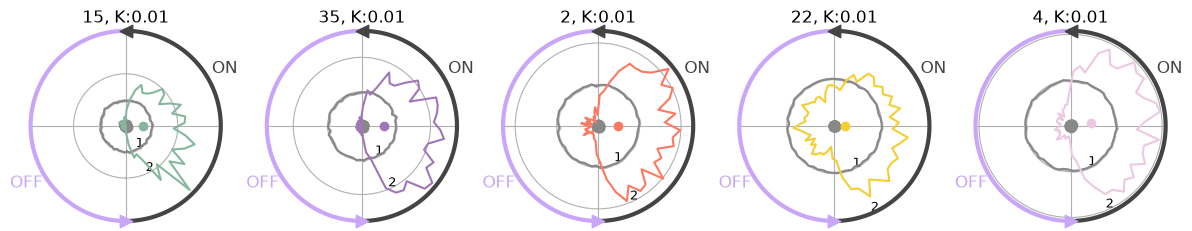

In [257]:
reg = 'nr'
this_K = skuramoto.sel(reg=reg)
this_tc = stuning_curve.sel(reg=reg)
fig, ax = fma.plotting.makeFigure(n=(1,5),size=(30,7),projection='polar')

to_plot = np.random.randint(0,len(this_K.reg),size=5)
for i, e in enumerate(to_plot):
    tk = this_K.isel(reg=e)
    tc = this_tc.isel(reg=e)
    ax[i].set_title(f'{e}, K: {tk.MC.values:.2f}')
    ax[i].scatter(tk.sel(val='psi',shuf=True),tk.sel(val='R',shuf=True),color=isru.paperColors('shuffle','d0'),zorder=9)
    ax[i].scatter(tk.sel(val='psi',shuf=False),tk.sel(val='R',shuf=False),color=isru.paperColors(i),zorder=10)
    fma.plotting.semPlot(tc.phi,tc.sel(shuf=True).T,color=isru.paperColors('shuffle'),ax=ax[i])
    ax[i].plot(stuning_curve.phi,tc.sel(shuf=False),color=isru.paperColors(i),zorder=11)
    isru.ISAxes(ax[i],yticks=[1,2])
do_save and fma.plotting.saveFigure(fig,froot / 'polar_example',['png','svg'])

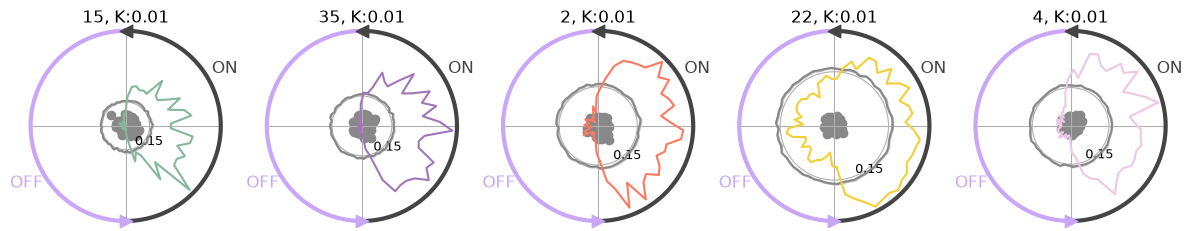

In [260]:
this_tc = sdist_transformed.sel(reg=reg)
fig, ax = fma.plotting.makeFigure(n=(1,5),size=(30,7),projection='polar')
for i, e in enumerate(to_plot):
    tk = this_K.isel(reg=e)
    tc = this_tc.isel(reg=e)
    ax[i].set_title(f'{e}, K:{tk.MC.values:.2f}')
    ax[i].scatter(tk.sel(val='psi',shuf=True),tk.sel(val='R',shuf=True),color=isru.paperColors('shuffle'))
    fma.plotting.semPlot(tc.phi,tc.sel(shuf=True).T,color=isru.paperColors('shuffle'),ax=ax[i])
    ax[i].plot(sdist_transformed.phi,tc.sel(shuf=False),color=isru.paperColors(i))
    isru.ISAxes(ax[i],yticks=[0.15])

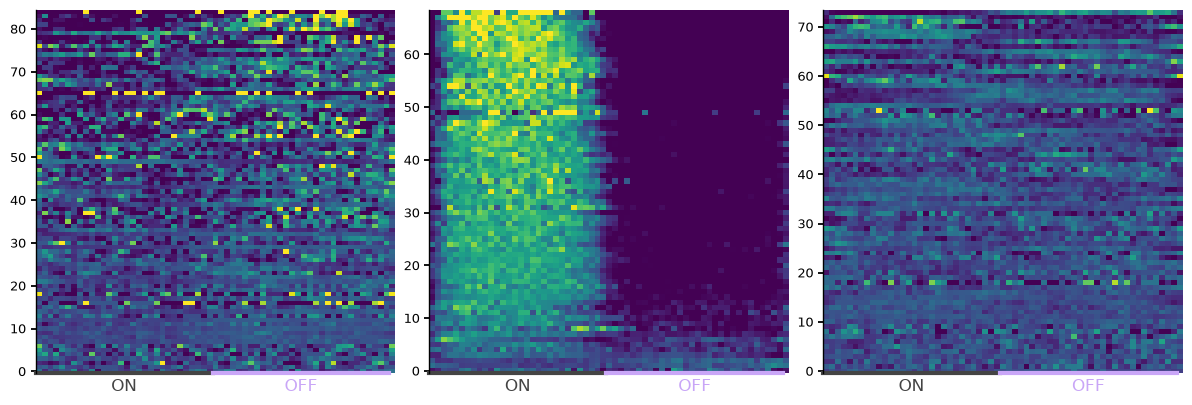

In [265]:
regs = np.unique(sdist.reg)
fig, ax = fma.plotting.makeFigure(n=(1,len(regs)),size=(30,10))
for i, r in enumerate(regs):
    order = np.argsort(skuramoto.sel(reg=r,val='R',shuf=False))
    fma.plotting.plotColorMap(stuning_curve.sel(reg=r,shuf=False),sortby=order,x=sdist.phi,ax=ax[i],vmin=0.5,vmax=2.5)
    isru.ISAxes(ax[i])

run batch

In [4]:
kuramoto, dist, tuning_curve, dist_transformed, isa_phase = fma.data.runBatch(batch_file,_unitISAPhaseVectorized,kwargs={'shuffle': 1000},parallel=True)
dist_transformed_cat = xr.concat([d for d in dist_transformed if d is not None],dim='reg',coords='different',join='outer')
#dist_transformed_avg = dist_transformed_cat.groupby('rat').mean(dim='rat',skipna=True)
tuning_curve_cat = xr.concat([d for d in tuning_curve if d is not None],dim='reg',coords='different',join='outer')
#tuning_curve_avg = tuning_curve_cat.groupby('rat').mean(dim='rat',skipna=True)
kuramoto_cat = xr.concat([d for d in kuramoto if d is not None],dim='reg',coords='different',join='outer')
kuramoto_cat = kuramoto_cat.assign_coords(h=('reg',(kuramoto_cat.MC < 0.05).values)) # threshold for significance
regs = ['nr','hpc','pfc']


Starting Batch, 2026-07-23 18:05:02.347356 

Error in session /mnt/hubel-data-131/perceval/Rat003_20231212/Rat003_20231212.xml (0)
zero-size array to reduction operation minimum which has no identity
Traceback:
Error in session /mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml (5)
zero-size array to reduction operation minimum which has no identity
Traceback:
Error in session /mnt/hubel-data-131/perceval/Rat003_20231222/Rat003_20231222.xml (7)
zero-size array to reduction operation minimum which has no identity
Traceback:
Error in session /mnt/hubel-data-131/perceval/Rat003_20231223/Rat003_20231223.xml (8)
zero-size array to reduction operation minimum which has no identity
Traceback:
Error in session /mnt/hubel-data-139/karadoc/Rat004_20240228/Rat004_20240228.xml (16)
zero-size array to reduction operation minimum which has no identity
Traceback:
Error in session /mnt/hubel-data-140/karadoc/Rat004_20240306/Rat004_20240306.xml (19)
zero-size array to reduction operation

/tmp/ipykernel_227353/3200118882.py:2: FutureWarning: In a future version of xarray the default value for compat will change from compat='equals' to compat='override'. This change will result in the following ValueError: Cannot specify both coords='different' and compat='override'. The recommendation is to set compat explicitly for this case.
  dist_transformed_cat = xr.concat([d for d in dist_transformed if d is not None],dim='reg',coords='different',join='outer')
/tmp/ipykernel_227353/3200118882.py:4: FutureWarning: In a future version of xarray the default value for compat will change from compat='equals' to compat='override'. This change will result in the following ValueError: Cannot specify both coords='different' and compat='override'. The recommendation is to set compat explicitly for this case.
  tuning_curve_cat = xr.concat([d for d in tuning_curve if d is not None],dim='reg',coords='different',join='outer')
/tmp/ipykernel_227353/3200118882.py:6: FutureWarning: In a future ve

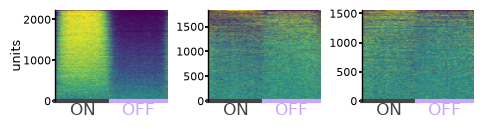

In [5]:
fig, ax = fma.plotting.makeFigure(n=(1,len(regs)),size=(12,3))
for i, r in enumerate(regs):
    tc = tuning_curve_cat.sel(reg=r)
    kur = kuramoto_cat.sel(reg=r)
    order = np.argsort(kur.sel(reg=r,val='R',shuf=False)).values
    fma.plotting.plotColorMap(tc.sel(reg=r,shuf=False),sortby=order,x=tc.phi,ax=ax[i],vmin=-1,vmax=1,zscore='all')
ax[0].set(ylabel='units'); isru.ISAxes(ax)

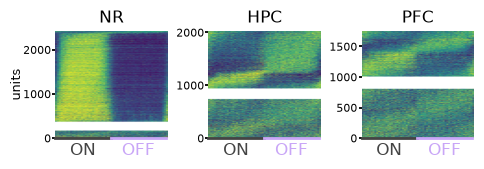

In [99]:
# MAYBE: thinner line On OFF, a bit more ticks padding
regs = ['nr','hpc','pfc']
fig, ax = fma.plotting.makeFigure(n=(1,len(regs)),size=(12,4))
for i, r in enumerate(regs):
    tc = tuning_curve_cat.sel(reg=r,shuf=False)
    kur = kuramoto_cat.sel(reg=r,val='psi',shuf=False)

    # separate in (non-)significantly entrained and sort separately
    signif = kur.h.values
    data_signif = tc.isel(reg=signif).values
    order = np.argsort(kur.isel(reg=signif)).values
    data_signif = data_signif[order]
    data_nsignif = tc.isel(reg=~signif).values
    order = np.argsort(kur.isel(reg=~signif)).values
    data_nsignif = data_nsignif[order]
    data = np.concatenate((data_nsignif, np.full((200,tc.shape[1]),np.nan), data_signif))

    fma.plotting.plotColorMap(data,x=tc.phi,ax=ax[i],vmin=-1,vmax=1,zscore='all')
    ax[i].set(title=r.upper()); ax[i].spines['left'].set_visible(False)
ax[0].set(ylabel='units'); isru.ISAxes(ax)
do_save and fma.plotting.saveFigure(fig,froot / 'color_map',['png','svg'])

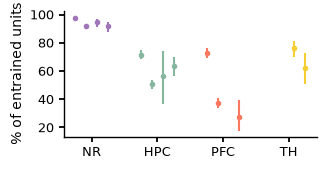

In [137]:
# proportion of entrained units MAKE PIE CHARTS!!
rats = np.unique(kuramoto_cat.rat)
regs = ['nr','hpc','pfc','th']
fig, ax = fma.plotting.makeFigure(size=(8,4))
dx = 0.25

for i, reg in enumerate(regs):
    data = np.full((len(rats),2),np.nan)
    for j, rat in enumerate(rats):
        this_data = kuramoto_cat.sel(reg=reg)
        if rat in this_data.rat:
            this_data = this_data.sel(rat=rat).h.values
            data[j,0] = this_data.sum()
            data[j,1] = len(this_data)
    low, high = smsp.proportion_confint(count=data[:,0],nobs=data[:,1],alpha=0.05,method='wilson')
    low = data[:,0]/data[:,1] - low
    high = high - data[:,0]/data[:,1]
    ax[0].errorbar(x=np.linspace(-1,1,len(rats))*dx+i,y=data[:,0]/data[:,1]*100,yerr=[low*100,high*100],ls='none',marker='.',color=isru.paperColors(reg))
ax[0].set(xticks=range(len(regs)),xticklabels=[r.upper() for r in regs],ylabel='% of entrained units');

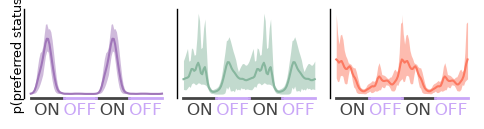

In [101]:
# preferred phase
regs = ['nr','hpc','pfc']
fig, ax = fma.plotting.makeFigure(n=(1,len(regs)),size=(12,3))
for i, r in enumerate(regs):
    kur = np.mod(kuramoto_cat.sel(reg=r,val='psi',shuf=False),2*np.pi)

    #data = tuple(kur.sel(rat=rat).isel(reg=~kur.h.sel(rat=rat)) for rat in np.unique(kur.rat))
    #x, y = fma.plotting.plotPDF(data,mode='polar',bandwidth=0.03,color='none',ax=ax[i])
    #fma.plotting.semPlot(x[0],y,color=isru.paperColors('shuffle'),ax=ax[i])

    data = tuple(kur.sel(rat=rat).isel(reg=kur.h.sel(rat=rat)) for rat in np.unique(kur.rat))
    x, y = fma.plotting.plotPDF(data,mode='polar',bandwidth=0.03,color='none',ax=ax[i])
    fma.plotting.semPlot(x[0],y,color=isru.paperColors(r),ax=ax[i])

    #fma.plotting.plotPDF(kur.isel(reg=~kur.h),mode='polar',bandwidth=0.03,color=isru.paperColors('shuffle'),ax=ax[i])
    #fma.plotting.plotPDF(kur.isel(reg=kur.h),mode='polar',bandwidth=0.03,color=isru.paperColors(r),ax=ax[i])
ax[0].set(ylabel='p(preferred status)')
isru.ISAxes(ax,double=True)
do_save and fma.plotting.saveFigure(fig,froot / 'psi_distribution',['png','svg'])

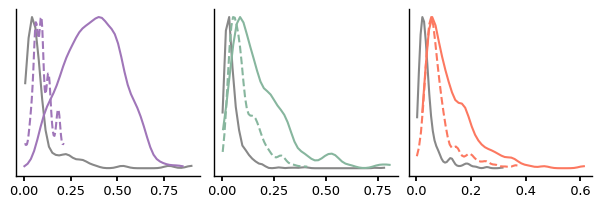

In [186]:
regs = ['nr','hpc','pfc']
fig, ax = fma.plotting.makeFigure(n=(1,len(regs)),size=(15,5))
for i, r in enumerate(regs):
    psi = np.mod(kuramoto_cat.sel(reg=r,val='psi',shuf=False),2*np.pi)
    perf_on = (psi.values > np.pi/4) & (psi.values < 3*np.pi/4)
    perf_off = (psi.values > 5*np.pi/4) & (psi.values < 7**np.pi/4)
    kur = np.mod(kuramoto_cat.sel(reg=r,val='R',shuf=False),2*np.pi)
    fma.plotting.plotPDF(kur.isel(reg=~kur.h),bandwidth=0.2,norm='max',color=isru.paperColors('shuffle'),ax=ax[i])
    fma.plotting.plotPDF(kur.isel(reg= kur.h & perf_on),bandwidth=0.2,norm='max',color=isru.paperColors(r),ax=ax[i])
    fma.plotting.plotPDF(kur.isel(reg= kur.h & perf_off),bandwidth=0.2,norm='max',color=isru.paperColors(r),ls='--',ax=ax[i])

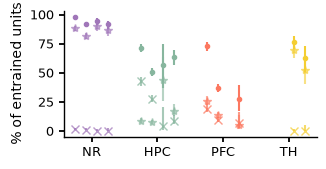

In [204]:
# proportion of units preferring ON or OFF
rats = np.unique(kuramoto_cat.rat)
regs = ['nr','hpc','pfc','th']
fig, ax = fma.plotting.makeFigure(size=(8,4))
dx = 0.25
limits = [[-1,10],[np.pi/4,3*np.pi/4],[5*np.pi/4,7*np.pi/4]]
transparency = ['ff','99','bb']
mark = ['.','*','x']

for i, reg in enumerate(regs):
    for k in range(3):
        data = np.full((len(rats),2),np.nan)
        for j, rat in enumerate(rats):
            this_data = kuramoto_cat.sel(reg=reg,shuf=False)
            psi = np.mod(this_data.sel(val='psi'),2*np.pi)
            prefer = (psi.values > limits[k][0]) & (psi.values < limits[k][1])
            if rat in this_data.rat:
                this_data = this_data.sel(rat=rat).h.values & prefer[this_data.rat==rat]
                data[j,0] = this_data.sum()
                data[j,1] = len(this_data)
        low, high = smsp.proportion_confint(count=data[:,0],nobs=data[:,1],alpha=0.05,method='wilson')
        low = data[:,0]/data[:,1] - low
        low[low<0] = 0
        high = high - data[:,0]/data[:,1]
        ax[0].errorbar(x=np.linspace(-1,1,len(rats))*dx+i,y=data[:,0]/data[:,1]*100,yerr=[low*100,high*100],ls='none',marker=mark[k],color=isru.paperColors(reg,transparency[k]))
ax[0].set(xticks=range(len(regs)),xticklabels=[r.upper() for r in regs],ylabel='% of entrained units');

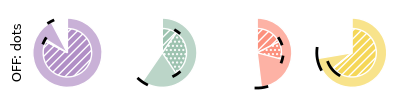

In [92]:
# proportion of units preferring ON or OFF
regs = ['nr','hpc','pfc','th']
fig, ax = fma.plotting.makeFigure(n=(1,len(regs)),size=(10,4))
limits = [[-1,10],[np.pi/4,3*np.pi/4],[5*np.pi/4,7*np.pi/4]]

for i, reg in enumerate(regs):
    kur = kuramoto_cat.sel(reg=reg,shuf=False)
    psi = np.mod(kur.sel(val='psi'),2*np.pi)
    data = np.full((3,2),np.nan)
    ci = np.full((3,2),np.nan)
    for k in range(3):
        prefer = (psi.values > limits[k][0]) & (psi.values < limits[k][1])
        this_data = kur.h.values & prefer
        data[k,0] = this_data.sum()
        data[k,1] = len(this_data)

        low, high = smsp.proportion_confint(count=data[k,0],nobs=data[k,1],alpha=0.05,method='wilson')
        ci[k] = (low, high)
    data = data[:,0] / data[:,1]

    ax[i].pie([data[0]],startangle=90,counterclock=False,normalize=False,radius=1,colors=[isru.paperColors(reg,'90')],wedgeprops={'edgecolor': 'w', 'lw': 1})
    #ax[i].pie([1-data[0]],startangle=90,normalize=False,radius=1,colors=[isru.paperColors('shuffle','90')],wedgeprops={'edgecolor': 'w', 'lw': 1})
    ax[i].pie([data[1]],startangle=90,counterclock=False,normalize=False,hatch='////',radius=.7,colors=[isru.paperColors(reg,'90')],wedgeprops={'edgecolor': 'w', 'lw': 1})
    ax[i].pie([data[2]],startangle=90-data[1]*360,counterclock=False,normalize=False,hatch='....',radius=.7,colors=[isru.paperColors(reg,'90')],wedgeprops={'edgecolor': 'w', 'lw': 1})
    # CI
    def polarPlot(r,t,**kw):
        t = np.linspace(t[0],t[1],1000)*2*np.pi + np.pi/2
        ax[i].plot(-r*np.cos(t), r*np.sin(t), **kw)
    if data[0] > 0.05:
        polarPlot(1.02,ci[0],color='k',lw=2)
    if data[1] > 0.05:
        polarPlot(.75,ci[1],color='k',lw=2)
    if data[2] > 0.05:
        polarPlot(.75,data[1]+ci[2],color='k',lw=2)

ax[0].set(ylabel='OFF: dots')
do_save and fma.plotting.saveFigure(fig,froot / 'on_off_pref',['png','svg'])